In [1]:
# Продолжайте развитие и анализ сгененированных данных.
# 4.1. На выбор, реализация текстурных характеристик:
#  - Признаки Тамура
#  - матрица взаимной встречаемости
# 4.2. На выбор, реализация алгоритма сегментации при помощи выбранного алгоритма кластеризации данных: 
# https://scikit-learn.ru/stable/modules/clustering.html
# 4.2.1 Если в кодировке пикселя не использовали его положение, выделите связные регионы.
# 4.3. На выбор, рассчитайте Качество проведенной сегментации на основе характеристик качества кластеризации: 
# https://scikit-learn.ru/stable/modules/clustering.html#clustering-evaluation 
# 4.4. Визуализируйте результат сегментации
# 4.5 Рассчитайте характеристики(описание формы) объектов.import cv2
# 4.6 Используя алгоритм кластеризации, найдите количество классов объектов на изображении.

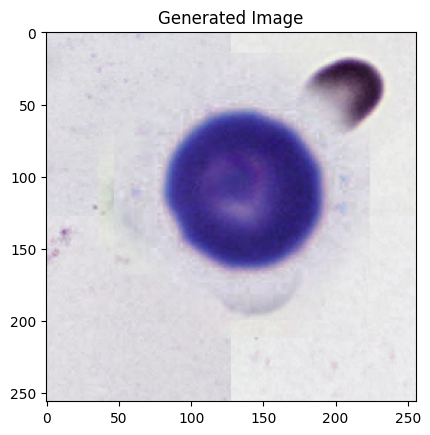

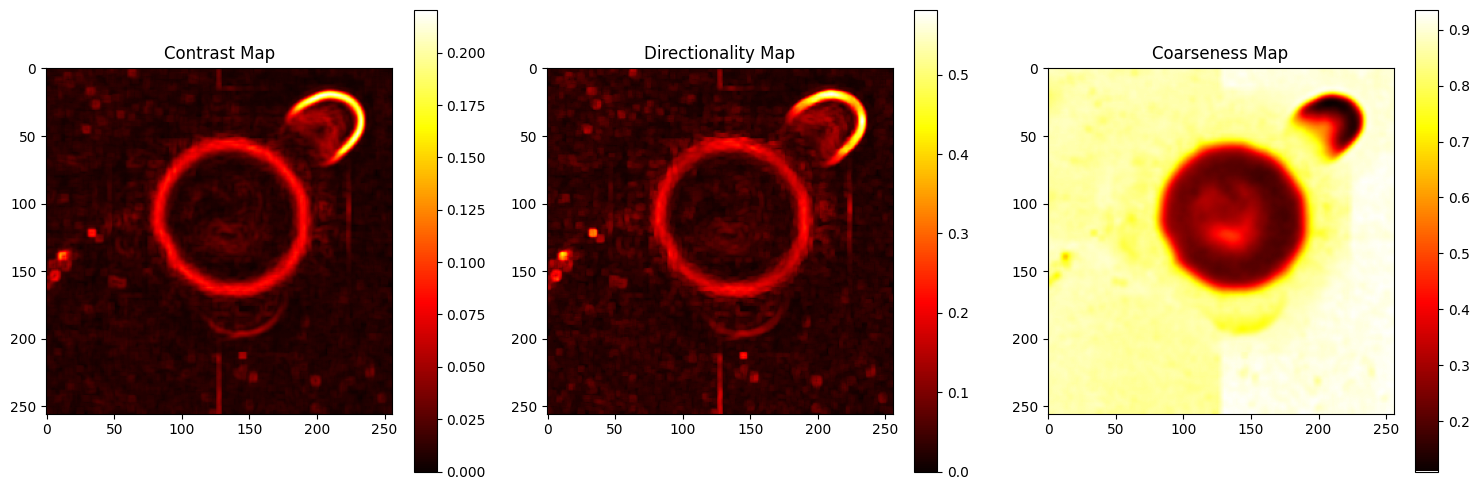

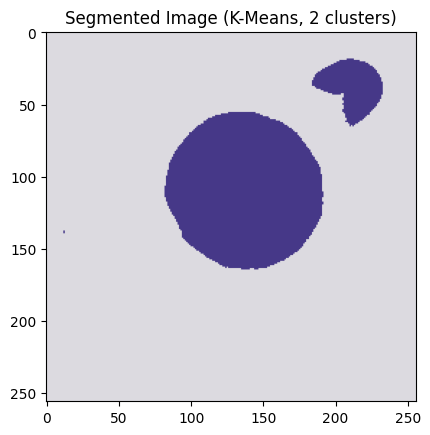

Segmentation Quality Metrics:
Silhouette Score: 0.8810
Davies-Bouldin Index: 0.2201

Object Properties Table:
   Object     Area   Perimeter  Eccentricity  Compactness  Orientation  \
0       1  55383.0  1537.87215      0.252105     0.023417     0.868196   

                                   Centroid  
0  (132.26322156618457, 124.15721430763953)  


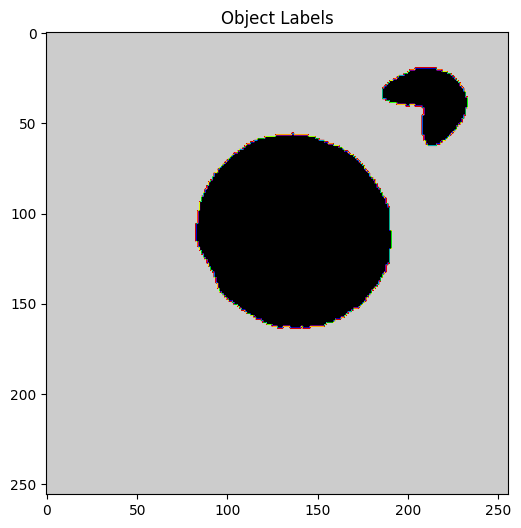

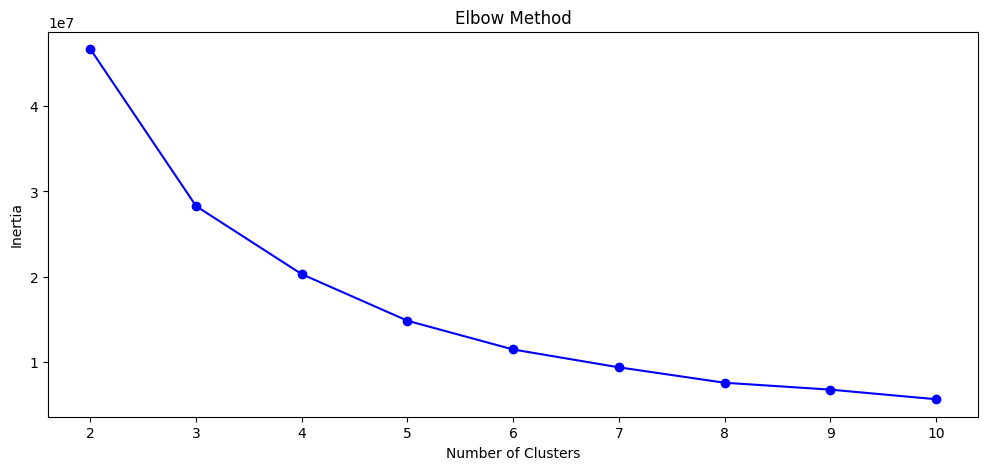

Optimal number of clusters: 10


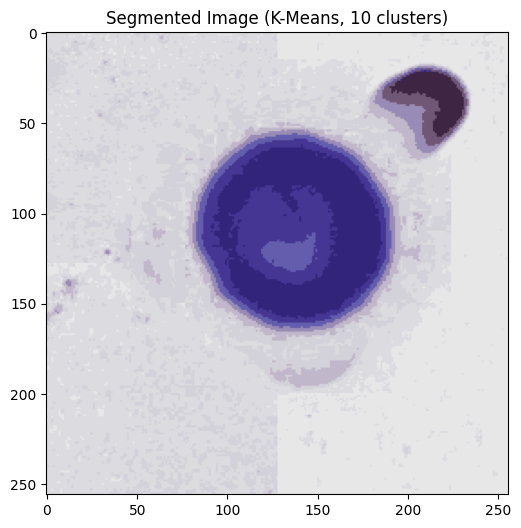

In [1]:
import os
import random
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage import color
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from skimage.measure import label, regionprops
import pandas as pd  

fon_path = "/Users/zuhroabdulloeva/Desktop/4 КУРС/cv/blood_cells_dataset/fon/"  
patch_path = "/Users/zuhroabdulloeva/Desktop/4 КУРС/cv/blood_cells_dataset/patch/"  

def load_patches_from_folder(folder_path):
    patches = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".png") or filename.endswith(".jpg"):
            img = cv2.imread(os.path.join(folder_path, filename))
            if img is not None:
                patches.append(img)
    return patches

def generate_background_from_patches(background_patches, num_patches=8, output_size=(256, 256)):
    selected_patches = random.choices(background_patches, k=num_patches)
    background = np.zeros((output_size[0], output_size[1], 3), dtype=np.uint8)
    patch_size = 128

    for i in range(0, output_size[0], patch_size):
        for j in range(0, output_size[1], patch_size):
            if selected_patches:
                patch = selected_patches.pop()
                if patch.shape[0] != patch_size or patch.shape[1] != patch_size:
                    patch = cv2.resize(patch, (patch_size, patch_size))
                try:
                    background[i:i+patch_size, j:j+patch_size] = patch
                except ValueError as e:
                    print(f"Error while placing patch: {e}")
                    continue
            else:
                break
    return background

def overlay_cells_on_background(background, cell_patches, num_cells=5):
    output = background.copy()
    for _ in range(num_cells):
        cell = random.choice(cell_patches)
        x = random.randint(0, background.shape[0] - cell.shape[0])
        y = random.randint(0, background.shape[1] - cell.shape[1])
        mask = np.zeros((cell.shape[0], cell.shape[1], 3), dtype=np.uint8)
        radius = min(cell.shape[0], cell.shape[1]) // 2
        cv2.circle(mask, (cell.shape[1] // 2, cell.shape[0] // 2), radius, (255, 255, 255), -1)
        mask = cv2.GaussianBlur(mask, (51, 51), 0)
        mask = mask.astype(np.float32) / 255.0

        for c in range(3):
            output[x:x+cell.shape[0], y:y+cell.shape[1], c] = (
                output[x:x+cell.shape[0], y:y+cell.shape[1], c] * (1 - mask[:, :, c]) +
                cell[:, :, c] * mask[:, :, c]
            )
    return output

background_folder = fon_path  
cells_folder = patch_path  

if not os.path.exists(background_folder):
    print(f"Error: Background folder '{background_folder}' not found.")
if not os.path.exists(cells_folder):
    print(f"Error: Cell folder '{cells_folder}' not found.")

background_patches = load_patches_from_folder(background_folder)
cell_patches = load_patches_from_folder(cells_folder)

background = generate_background_from_patches(background_patches)
output_image = overlay_cells_on_background(background, cell_patches)

plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title("Generated Image")
plt.show()

def compute_tamura_feature_maps(image, window_size=5):
    gray = color.rgb2gray(image)
    gray = gray.astype(np.float32)

    pad = window_size // 2
    padded = np.pad(gray, pad, mode='reflect')
    h, w = gray.shape

    contrast_map = np.zeros_like(gray)
    directionality_map = np.zeros_like(gray)
    coarseness_map = np.zeros_like(gray)

    for i in range(h):
        for j in range(w):
            window = padded[i:i+window_size, j:j+window_size]

            # Contrast
            contrast_map[i, j] = np.std(window)

            # Directionality
            grad_x = cv2.Sobel(window, cv2.CV_64F, 1, 0, ksize=3)
            grad_y = cv2.Sobel(window, cv2.CV_64F, 0, 1, ksize=3)
            magnitude = np.sqrt(grad_x**2 + grad_y**2)
            directionality_map[i, j] = np.std(magnitude)

            # Coarseness
            coarseness_map[i, j] = np.mean(window)

    return {
        'contrast_map': contrast_map,
        'directionality_map': directionality_map,
        'coarseness_map': coarseness_map
    }

tamura_maps = compute_tamura_feature_maps(output_image, window_size=5)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(tamura_maps['contrast_map'], cmap='hot')
plt.title('Contrast Map')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(tamura_maps['directionality_map'], cmap='hot')
plt.title('Directionality Map')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(tamura_maps['coarseness_map'], cmap='hot')
plt.title('Coarseness Map')
plt.colorbar()

plt.tight_layout()
plt.show()

def segment_image_kmeans(image, n_clusters=3):
    pixel_values = image.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(pixel_values)

    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    centers = np.uint8(centers)
    segmented_image = centers[labels.flatten()]
    segmented_image = segmented_image.reshape(image.shape)

    return segmented_image, labels.reshape(image.shape[:2])

n_clusters = 2
segmented_image, labels = segment_image_kmeans(output_image, n_clusters=n_clusters)

plt.imshow(cv2.cvtColor(segmented_image, cv2.COLOR_BGR2RGB))
plt.title(f"Segmented Image (K-Means, {n_clusters} clusters)")
plt.show()

def evaluate_segmentation(image, labels):
    pixel_values = image.reshape((-1, 3))

    silhouette_avg = silhouette_score(pixel_values, labels.flatten())
    davies_bouldin = davies_bouldin_score(pixel_values, labels.flatten())

    return {
        'silhouette_score': silhouette_avg,
        'davies_bouldin_index': davies_bouldin
    }

evaluation_metrics = evaluate_segmentation(output_image, labels)

print("Segmentation Quality Metrics:")
print(f"Silhouette Score: {evaluation_metrics['silhouette_score']:.4f}")
print(f"Davies-Bouldin Index: {evaluation_metrics['davies_bouldin_index']:.4f}")

def analyze_object_properties(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary_image = cv2.threshold(gray_image, 128, 255, cv2.THRESH_BINARY)
    labeled_image = label(binary_image)
    regions = regionprops(labeled_image)

    object_properties = []
    for i, region in enumerate(regions):
        perimeter = region.perimeter
        compactness = region.area / (perimeter ** 2) if perimeter > 0 else 0  

        object_properties.append({
            'Object': i + 1,
            'Area': region.area,
            'Perimeter': perimeter,
            'Eccentricity': region.eccentricity,
            'Compactness': compactness,  
            'Orientation': region.orientation,
            'Centroid': region.centroid
        })
    
    df = pd.DataFrame(object_properties)

    print("\nObject Properties Table:")
    print(df)

    plt.figure(figsize=(12, 6))
    plt.imshow(labeled_image, cmap='nipy_spectral')
    plt.title("Object Labels")
    plt.show()

analyze_object_properties(output_image)

def find_optimal_clusters(image, max_clusters=10):
    pixel_values = image.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)

    distortions = []
    K = range(2, max_clusters + 1)
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(pixel_values)
        distortions.append(kmeans.inertia_)

    plt.figure(figsize=(12, 5))
    plt.plot(K, distortions, 'bo-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.title('Elbow Method')
    plt.show()

    optimal_k = K[np.argmin(distortions)]  
    print(f"Optimal number of clusters: {optimal_k}")

    return optimal_k

optimal_clusters = find_optimal_clusters(output_image, max_clusters=10)

segmented_image, labels = segment_image_kmeans(output_image, optimal_clusters)

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(segmented_image, cv2.COLOR_BGR2RGB))
plt.title(f"Segmented Image (K-Means, {optimal_clusters} clusters)")
plt.show()